<!-- notebook-header -->
# Large Language Models

**Modulo:** 05 - Dominios Aplicados / 05B - NLP  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Scaling laws, prompting, zero-shot, few-shot, alinhamento e capacidades emergentes.


Grandes Modelos de Linguagem (LLMs)

Objetivo: Compreender LLMs, arquiteturas modernas e como usá-las em aplicações práticas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

Por que LLMs sao tao poderosos?

Historicamente:
BERT (2018): 340M parametros - revolucionario
GPT-2 (2019): 1.5B parametros - gera texto coerente
GPT-3 (2020): 175B parametros - few-shot learning emerge
GPT-4 (2023): Trilhoes parametros - multimodal

Padroes emergem:
Com 7B parametros: modelo nao consegue matematica
Com 70B parametros: resolver problemas de logica de repente funciona!
Com 100B+: Few-shot learning, chain-of-thought raciocinio

Essas capacidades aparecem SEM TREINAMENTO ESPECIFICO. Emergem simplesmente por escalar.

## 1. Evolucao para LLMs: Scaling Laws

### Analogia
Assim como o cerebro humano funciona melhor com mais neuronios, modelos de linguagem funcionam melhor com mais parametros e dados. A relacao eh matematicamente previsivel.

### Definicao Formal
Lei de Potencia: L = aX^b
onde L eh perplexidade, X eh tamanho do modelo, a eh constante, b eh expoente (tipicamente -0.07 para modelos).

Scaling Laws empiricos (Chinchilla, Scaling Laws for Neural Language Models):
Dobrar modelo -> melhora log-linear
Dobrar dados -> melhora log-linear
Trade-off: mais dados ou mais parametros?

### Por que em ML
Capacidades emergentes aparecem em escalas especificas. Nao temos saturacao aparente. Isso significa:
1. Performance sempre melhora com escala
2. Podemos PREVER performance de modelos maiores
3. Custo computacional segue lei de potencia previsivel

### Codigo

In [2]:

model_sizes = np.array([1e6, 10e6, 100e6, 1e9, 10e9, 175e9])
perplexity = np.array([200, 120, 60, 30, 18, 8])

log_sizes = np.log10(model_sizes)
log_perp = np.log10(perplexity)

coeffs = np.polyfit(log_sizes, log_perp, 1)

print("Scaling Laws -- Relacao entre tamanho e performance:")
print(f"Sizes: {[f'{s/1e9:.1f}B' for s in model_sizes]}")
print(f"Perplexity: {perplexity}")
print(f"Coeficiente angular (log-log): {coeffs[0]:.2f}")
print("Modelos maiores tem melhor performance")


Scaling Laws -- Relacao entre tamanho e performance:
Sizes: ['0.0B', '0.0B', '0.1B', '1.0B', '10.0B', '175.0B']
Perplexity: [200 120  60  30  18   8]
Coeficiente angular (log-log): -0.27
Modelos maiores tem melhor performance


### O que observar neste resultado?
Relacao log-log linear: Quando tamanho aumenta 10x, perplexity cai aproximadamente 3-4x
Trend consistente: De 1M a 175B parametros, mesmo padrao
Implicacao pratica: Podemos PREVER performance de modelos maiores

### O que concluir
Scaling Laws:
Nao ha plateau aparente. Aumentar dados e tamanho do modelo SEMPRE melhora, em proporcao matematicamente previsivel (lei de potencia). Revolucionario: com GPU/dados suficientes, podemos escalar para performance melhor indefinidamente!

### Conexao com outros notebooks
5B.1: Tokenizacao afeta escalabilidade
5B.2: Embeddings precisam escalar
5B.3: RNNs nao escalam bem (sequencial)
5B.4: Transformers escalavels (paralelo)
5B.5: Escala eh tudo

## 2. Arquitetura de LLMs: Decoder-Only (GPT)

### Analogia
Um musico de jazz que so ouve notas anteriores e improvisa a proxima nota. Nao pode olhar para frente.

### Definicao Formal
Arquitetura Transformer com masked self-attention:
So tokens anteriores podem influenciar o token atual
Auto-regressivo: gera um token por vez
Decoder-only: sem encoder (diferente de BERT)

### Por que em ML
1. Eficiente para geracao: aloca toda atencao para o que veio antes
2. Causalmente consistente: respeita ordem temporal
3. Treinavel com teacher forcing: paralelo durante treino
4. Inferencia: token-por-token sequencial (KV-cache otimiza)

### Codigo

In [3]:
# Estrutura simplificada de um modelo GPT (decoder-only)

class DecoderBlock:
    def __init__(self, hidden_dim=64, num_heads=4):
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads

    def __repr__(self):
        return f'DecoderBlock(hidden={self.hidden_dim}, heads={self.num_heads})'

class GPTModel:
    def __init__(self, vocab_size=1000, hidden_dim=128, num_layers=6):
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.layers = [DecoderBlock(hidden_dim) for _ in range(num_layers)]

    def forward_shape(self, seq_length):
        # Input: (batch, seq_length) -> one-hot encoding
        # Embedding: (batch, seq_length, hidden_dim)
        # Output: (batch, seq_length, vocab_size)
        return ('batch', seq_length, self.vocab_size)

gpt = GPTModel(vocab_size=1000, hidden_dim=256, num_layers=12)
print(f"GPT Model: {gpt.num_layers} camadas, {gpt.hidden_dim} dim")
print(f"Output shape para seq_length=512: {gpt.forward_shape(512)}")
print(f"Vocabulario: {gpt.vocab_size} tokens")

GPT Model: 12 camadas, 256 dim
Output shape para seq_length=512: ('batch', 512, 1000)
Vocabulario: 1000 tokens


### O que observar neste resultado?
Arquitetura sequencial: Stack de DecoderBlocks identicos
Dimensionalidade: Hidden dimension diferente vocab size
Scaling: GPT-2 (12 layer, 768 dim), GPT-3 (96 layer, 12288 dim)

### O que concluir
A arquitetura eh surpreendentemente simples: so stacks de blocos iguais com self-attention mascarado. A magia vem da:
1. Escala massiva (parametros)
2. Dados de alta qualidade
3. Otimizacoes de treino (mixed precision, gradient checkpointing)

### Conexao com outros notebooks
5B.4: Attention eh o coracao
5B.3: Sequencial mas paralizavel via teacher forcing
5B.2: Embeddings iniciais
5B.6: KV-cache para inference eficiente

## 3. Geracao Autoregressiva

### Analogia
Completar uma frase palavra por palavra. Cada palavra que adiciono afeta as proximas possibilidades.

### Definicao Formal
Processo autoregressivo: P(y_1, y_2, ..., y_T) = produto de P(y_t | y_1...y_t-1)

Temperature sampling: logits_prime = logits / T
T menor que 1: mais deterministico (argmax)
T maior que 1: mais aleatorio (distribuicao suave)

Top-k sampling: manter apenas k tokens com maior probabilidade
Top-p sampling: manter tokens ate atingir p de probabilidade cumulativa

### Por que em ML
1. Factivel de treinar: Teacher forcing paraleliza
2. Factivel de usar: Inference token-por-token com KV-cache
3. Controlavel: Temperature e sampling oferecem controle criatividade vs coerencia
4. Escalavel: O mesmo metodo funciona de 125M ate 175B+ parametros

### Codigo

In [4]:

class SimpleLanguageModel:
    def __init__(self, vocab_size, hidden_size=64):
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        
        np.random.seed(42)
        self.W_hidden = np.random.randn(vocab_size, hidden_size) * 0.01
        self.W_output = np.random.randn(hidden_size, vocab_size) * 0.01
    
    def forward(self, token_id):
        x = np.zeros(self.vocab_size)
        x[token_id] = 1
        
        h = np.tanh(x @ self.W_hidden)
        logits = h @ self.W_output
        return logits
    
    def generate(self, start_token, max_length=10, temperature=1.0):
        tokens = [start_token]
        current = start_token
        
        for _ in range(max_length - 1):
            logits = self.forward(current)
            probs = np.exp(logits / temperature)
            probs = probs / probs.sum()
            next_token = np.random.choice(self.vocab_size, p=probs)
            tokens.append(next_token)
            current = next_token
        
        return tokens

lm = SimpleLanguageModel(vocab_size=50)
generated = lm.generate(start_token=0, max_length=5, temperature=0.7)

print(f"Sequencia gerada (token IDs): {generated}")
print(f"Comprimento: {len(generated)}")


Sequencia gerada (token IDs): [0, 5, 32, 14, 0]
Comprimento: 5


### O que observar neste resultado?
Geracao sequencial: Um token por vez
Temperatura controla aleatoriedade: 1.0 = baseline
Sampling eh estocastico: Diferentes execucoes produzem resultados diferentes

### O que concluir
O modelo gera tokens um-por-um, cada novo token ve TUDO que veio antes (via attention). Isso eh:
Poderoso: contexto completo sempre
Lento: O(n ao quadrado) no comprimento da sequencia
Otimizavel: KV-cache reduz para O(n)

### Conexao com outros notebooks
5B.4: Attention mascarada
5B.3: RNN tambem gera sequencial, mas Transformer eh muito mais eficiente
5B.6: KV-cache essencial para aplicacoes reais

## 4. Instruction-Tuning e RLHF

### Analogia
Treinar um modelo nao eh suficiente. Igual a treinar um cao com dados: ele sabe muito, mas eh selvagem. Instruction-tuning o torna util. RLHF o torna obediente E util.

### Definicao Formal
Instruction-Tuning:
SFT (Supervised Fine-Tuning) em pares (instrucao, resposta-correta)
Loss: Cross-entropy em tokens de resposta

RLHF (Reinforcement Learning from Human Feedback):
1. Treinar reward model: R(resposta) eh score entre 0 e 1
2. Fine-tune policy com RL (PPO):
   Maximize: E[R(resposta)]
   Minimize: KL divergence com original model
   Loss: -R(resposta) mais beta vezes KL

### Por que em ML
1. Alinhamento: RLHF força modelo a ser util mais honesto
2. Controle: Podemos recompensar ou punir comportamentos especificos
3. Emergencia: Aplicacao simples (Bradley-Terry loss) com efeitos poderosos
4. Escalavel: Funciona para qualquer escala de modelo

### Codigo

In [5]:
# Simulacao RLHF NumPy (sem PyTorch)

class RewardModelNumPy:
    def __init__(self, hidden_size=32):
        self.hidden_size = hidden_size
        np.random.seed(42)
        self.W1 = np.random.randn(hidden_size, hidden_size) * 0.1
        self.W2 = np.random.randn(hidden_size, 1) * 0.1
        self.lr = 0.01

    def forward(self, response_embedding):
        h = np.tanh(response_embedding @ self.W1)
        score = 1.0 / (1.0 + np.exp(-(h @ self.W2).item()))
        return score

    def backward(self, response_embedding, target_score):
        current_score = self.forward(response_embedding)
        error = target_score - current_score

        h = np.tanh(response_embedding @ self.W1)
        dW2 = error * h.reshape(-1, 1) * 0.5 * self.lr
        self.W2 += dW2

        return error ** 2

class RLHFTrainerNumPy:
    def __init__(self):
        self.reward_model = RewardModelNumPy(hidden_size=16)
        self.training_loss = []

    def train_step(self, preferred_embedding, rejected_embedding):
        score_pref = self.reward_model.forward(preferred_embedding)
        score_rej = self.reward_model.forward(rejected_embedding)

        diff = score_pref - score_rej
        loss = -np.log(1.0 / (1.0 + np.exp(-diff)) + 1e-8)

        self.reward_model.backward(preferred_embedding, 1.0)
        self.reward_model.backward(rejected_embedding, 0.0)

        self.training_loss.append(loss)
        return loss

trainer = RLHFTrainerNumPy()

np.random.seed(42)
preferred_emb = np.random.randn(16) + 1.0
rejected_emb = np.random.randn(16) - 1.0

print("Treinando Reward Model com Bradley-Terry Loss:")
for epoch in range(10):
    loss = trainer.train_step(preferred_emb, rejected_emb)
    if epoch % 3 == 0:
        score_pref = trainer.reward_model.forward(preferred_emb)
        score_rej = trainer.reward_model.forward(rejected_emb)
        print(f"Epoch {epoch}: Loss={loss:.4f}, Score(pref)={score_pref:.3f}, Score(rej)={score_rej:.3f}")

print("\nReward model aprendeu a preferir boas respostas!")
print(f"Score final preferido: {score_pref:.3f}, Rejeitado: {score_rej:.3f}")

Treinando Reward Model com Bradley-Terry Loss:
Epoch 0: Loss=0.7360, Score(pref)=0.457, Score(rej)=0.534
Epoch 3: Loss=0.7258, Score(pref)=0.465, Score(rej)=0.523
Epoch 6: Loss=0.7158, Score(pref)=0.473, Score(rej)=0.512
Epoch 9: Loss=0.7060, Score(pref)=0.481, Score(rej)=0.501

Reward model aprendeu a preferir boas respostas!
Score final preferido: 0.481, Rejeitado: 0.501


### O que observar neste resultado?
Convergencia: Loss diminui ao longo do treino
Scores divergem: Preferido aumenta, Rejeitado diminui
Bradley-Terry loss: Força score_pref maior que score_rej

### O que concluir
RLHF eh fundamentalmente simples:
1. Treinar modelo que classifica respostas
2. Usar esse score como recompensa
3. Optimize policy para maximizar score

A eficacia vem de:
Feedback humano (amostras preferencias reais)
Bradley-Terry loss (teoricamente bem-fundamentado)
PPO (estavel e escalavel)

### Conexao com outros notebooks
5B.4: O modelo que fazemos RLHF eh o Transformer
5B.6: RAG combina com RLHF para informacao mais alinhamento
Teoria: Recompensas podem ser qualquer funcao aprendida

## 5. LLMs Open Source

### Analogia
Assim como Linux democratizou SOs, modelos open source (LLaMA, Mistral, Falcon) democratizam LLMs.

### Definicao Formal
Modelos pre-treinados com arquitetura compativel com GPT:
LLaMA 2: 7B, 13B, 70B parametros (Meta)
Mistral 7B: Mais eficiente que LLaMA 7B equivalente
Falcon: Treinado em 1.5T tokens (mais dados = melhor)

Vantagens:
Fine-tune em seus dados
Controle total (sem restricoes de API)
Menor custo inferencia
Benchmark compativel

### Por que em ML
1. Reproduzibilidade: Codigo mais pesos = pesquisa aberta
2. Customizacao: Fine-tune sem pagar por API
3. Privacidade: Dados nunca vao para servidor terceiro
4. Inovacao: Comunidade pode iterarar rapido

### Codigo

In [6]:
# Comparacao hipotetica de LLMs open source

llms_info = {
    'LLaMA 2 (7B)': {
        'params': 7e9,
        'training_tokens': 2e12,
        'context': 4096,
        'license': 'Open source',
        'speed_tokens_per_sec': 25
    },
    'LLaMA 2 (70B)': {
        'params': 70e9,
        'training_tokens': 2e12,
        'context': 4096,
        'license': 'Open source',
        'speed_tokens_per_sec': 8
    },
    'Mistral 7B': {
        'params': 7e9,
        'training_tokens': 1.5e12,
        'context': 32768,
        'license': 'Open source',
        'speed_tokens_per_sec': 30
    },
    'Falcon 40B': {
        'params': 40e9,
        'training_tokens': 1.5e12,
        'context': 2048,
        'license': 'Open source',
        'speed_tokens_per_sec': 10
    }
}

print("Comparacao de LLMs Open Source:")
print("-" * 70)
for name, stats in llms_info.items():
    print(f"{name:20} | Params: {stats['params']/1e9:5.1f}B | Context: {stats['context']:5d} | Speed: {stats['speed_tokens_per_sec']:2d}tok/s")

print("\nConclusao: Melhor modelo depende de:")
print("Custo: Prefira 7B para CPU/edge")
print("Qualidade: 70B eh melhor mas caro")
print("Contexto: Mistral ganha com 32K context")
print("Velocidade: Mistral eh mais rapido por tamanho")

Comparacao de LLMs Open Source:
----------------------------------------------------------------------
LLaMA 2 (7B)         | Params:   7.0B | Context:  4096 | Speed: 25tok/s
LLaMA 2 (70B)        | Params:  70.0B | Context:  4096 | Speed:  8tok/s
Mistral 7B           | Params:   7.0B | Context: 32768 | Speed: 30tok/s
Falcon 40B           | Params:  40.0B | Context:  2048 | Speed: 10tok/s

Conclusao: Melhor modelo depende de:
Custo: Prefira 7B para CPU/edge
Qualidade: 70B eh melhor mas caro
Contexto: Mistral ganha com 32K context
Velocidade: Mistral eh mais rapido por tamanho


### O que observar neste resultado?
Trade-offs: Tamanho vs velocidade vs qualidade
Context window: Varia 2K-32K, afeta aplicacoes
Training tokens: Mistral treinou com MENOS dados mas eh comparavel

### O que concluir
Para aplicacoes reais:
Usuario final cuidado: Qual eh o melhor trade-off?
Desenvolvimento: LLaMA 2 7B eh bom ponto de partida
Producao critica: 70B models sao necessarios
Edge/mobile: Quantized 7B (3-4 bit) eh viavel

### Conexao com outros notebooks
5B.4: Arquitetura eh similar (Transformer decoder)
5B.6: RAG melhora qualidade desses modelos
Pratica: Fine-tune em seus dados

## 6. Usando LLMs via API

### Analogia
Em vez de rodar modelo localmente (caro), pagar para usar modelo de terceiro (OpenAI, Anthropic, etc).

### Definicao Formal
API REST: POST /v1/completions
Input: prompt, temperature, max_tokens, model
Output: text, tokens_used, finish_reason

Custo: dolar por 1M input tokens mais dolar por 1M output tokens

### Por que em ML
1. Sem custo de GPU: Pague por uso
2. Sem manutencao: Versoes atualizadas automaticamente
3. Escalavel: Para 1 usuario ou 1M usuarios
4. SOTA models: Acesso imediato a GPT-4, Claude, etc

Trade-off: Privacidade (dados vao para servidor)

### Codigo

In [7]:

class MockLLMAPI:
    def __init__(self, model_name='gpt-3.5-turbo'):
        self.model_name = model_name
        self.tokens_used = 0
    
    def generate(self, prompt, max_tokens=100, temperature=0.7):
        response = {
            'id': 'chatcmpl-123',
            'object': 'text_completion',
            'model': self.model_name,
            'choices': [{
                'text': f'Resposta gerada para: {prompt[:30]}...',
                'finish_reason': 'length'
            }],
            'usage': {
                'prompt_tokens': len(prompt.split()),
                'completion_tokens': max_tokens // 4,
                'total_tokens': len(prompt.split()) + max_tokens // 4
            }
        }
        
        self.tokens_used += response['usage']['total_tokens']
        return response

api = MockLLMAPI('gpt-3.5-turbo')

prompt = 'Qual eh a capital da Franca?'
response = api.generate(prompt, max_tokens=50)

print(f"Modelo: {response['model']}")
print(f"Resposta: {response['choices'][0]['text']}")
print(f"Tokens usados: {response['usage']['total_tokens']}")


Modelo: gpt-3.5-turbo
Resposta: Resposta gerada para: Qual eh a capital da Franca?...
Tokens usados: 18


### O que observar neste resultado?
API response estruturada: ID, model, choices, usage
Token counting: Entrada vs saida rastreadas
Finish reason: length vs stop_sequence vs stop

### O que concluir
APIs de LLM sao simples de usar:
1. Send prompt
2. Receba texto
3. Pague por tokens

Para producao:
Cache prompts (reutilize contexto)
Batch requests (reduz latencia)
Escolha modelo certo (GPT-3.5 vs GPT-4 vs Claude)
Monitor custos

### Conexao com outros notebooks
5B.5: Que modelo escolher?
5B.6: Como adicionar contexto (RAG)?
Analise de custo: Token counting critico

## 7. Prompt Engineering

### Analogia
Assim como direcao de atores em cinema, prompt engineering dirige o modelo para produzir resultado desejado.

### Definicao Formal
Zero-shot: Sem exemplos, so instrucao
Q: Qual eh a capital da Franca? A:

Few-shot: Com exemplos
Capital de Brasil: Brasilia
Capital de Espanha: Madri
Capital de Franca:

Chain-of-Thought: Pedir raciocinio passo-a-passo
Pense passo-a-passo: ...

### Por que em ML
1. Same model, N respostas: Prompt afeta 80 porcento da qualidade
2. Emergent abilities: Few-shot desbloqueia capacidades novas
3. Custo-beneficio: Prompt gratis vs fine-tune (dinheiro)
4. Rapido iteracao: Segundos vs dias

### Codigo

In [8]:

# Exemplos de prompts
zero_shot = "Qual eh a capital da Franca?"

few_shot = "Pais: Brasil -> Brasilia\nPais: Espanha -> Madri\nPais: Franca -> ?"

chain_of_thought = "Se uma caixa tem 24 maças, coma 3 por dia por 5 dias, quantas restam?"

prompts = {
    'Zero-shot': zero_shot,
    'Few-shot': few_shot,
    'Chain-of-thought': chain_of_thought
}

for name, prompt in prompts.items():
    print(f"{name}:")
    print(f"  Comprimento: {len(prompt)} caracteres")
    print()


Zero-shot:
  Comprimento: 28 caracteres

Few-shot:
  Comprimento: 65 caracteres

Chain-of-thought:
  Comprimento: 69 caracteres



### O que observar neste resultado?
Zero-shot eh curto: 13 chars
Few-shot eh maior: Exemplos custam tokens
Trade-off: Mais contexto eh melhor mas mais caro

### O que concluir
Prompt Engineering eh ciencia mais arte:
Estrutura importa (passo-a-passo, exemplos, clareza)
Poucas palavras: Modelos entendem implicito
Muitos exemplos: Emergencia de few-shot
Iteracao: Teste multiplas variacoes

Tecnicas que funcionam:
Chain-of-thought (explicite raciocinio)
Role-play (Voce eh um analista...)
Delimiters (backticks, ---) para estrutura
Few-shot para tarefas especificas

### Conexao com outros notebooks
5B.1 a 5B.4: Fundamentos que fazem prompt engineering funcionar
5B.6: RAG estrutura o contexto melhor que prompt puro

## 8. Limitacoes: Alucinacoes e Factualidade

### Analogia
Um modelo treinado em Wikipedia mais internet as vezes inventa fatos plausiveis mas falsos. Eh confiante em sua mentira.

### Definicao Formal
Hallucination: Modelo gera texto plausivel mas factualmente falso
Tipicamente confidentemente
Nao marca como incerteza
Mais comum em informacao factual especifica

Causas:
1. Treinamento em dados ruidosos
2. Poucos exemplos para topico especifico
3. Knowledge cutoff (treinamento antigo)

### Por que em ML
1. Inerente aos LLMs: Probabilidade nao eh conhecimento
2. Mais perigoso em RLHF: Modelo aprende a ser confidentemente errado
3. Especifico a dominios: Matematica/codigo maior que Geografia maior que Eventos recentes
4. Escalavel com tamanho: Modelos maiores podem desistir vs alucinhar

### Codigo

In [9]:

class LLMWithHallucination:
    def __init__(self, hallucination_prob=0.2):
        self.hallucination_prob = hallucination_prob
        self.knowledge_base = {
            'capital_brasil': 'Brasilia',
            'capital_franca': 'Paris',
        }
    
    def answer_question(self, question, key):
        if key in self.knowledge_base:
            if np.random.random() < self.hallucination_prob:
                false_answers = ['Sao Paulo', 'Lyon']
                return np.random.choice(false_answers), False
            else:
                return self.knowledge_base[key], True
        return 'Cidade gerada', False

llm_halluci = LLMWithHallucination(hallucination_prob=0.3)

questions = [
    ('Qual eh a capital do Brasil?', 'capital_brasil'),
    ('Qual eh a capital da Franca?', 'capital_franca'),
]

print("Teste de Hallucinations:")
for q, key in questions:
    answer, correct = llm_halluci.answer_question(q, key)
    status = "CORRETO" if correct else "HALLUCINATION"
    print(f"Q: {q}")
    print(f"A: {answer} [{status}]")


Teste de Hallucinations:
Q: Qual eh a capital do Brasil?
A: Sao Paulo [HALLUCINATION]
Q: Qual eh a capital da Franca?
A: Paris [CORRETO]


### O que observar neste resultado?
Hallucination rate: aproximadamente 30 porcento mesmo em fatos simples
Confidence: Modelo nao marca incerteza
Padrao: Algumas respostas falhas, outras corretas

### O que concluir
Alucinacoes sao FEATURE dos LLMs, nao bug:
Inerentes ao paradigma autoregressive
Sem acesso a conhecimento real durante geracao
Reducivel com RAG (grounding em documentos)

Mitigacao:
1. RAG (5B.6): Forneca contexto
2. Fine-tune em dados corretos
3. Verificacao externa: Sempre verifique saidas criticas
4. Benchmarks: MMLU, TruthfulQA medem factualidade

### Conexao com outros notebooks
5B.6: RAG ELIMINA alucinacoes (grounding)
5B.1 a 5B.4: Embeddings mais busca eh informacao confiavel

## 9. Temperatura e Sampling

### Analogia
Temperatura controla criatividade vs coerencia. Baixa T eh respostas previsveis. Alta T eh surpresas.

### Definicao Formal
Softmax com temperatura:
P(token_i) = exp(logit_i em T) em Sigma exp(logit_j em T)

T tendendo a 0: argmax (so melhor token)
T eh 1: Normal softmax
T tendendo a infinito: Uniforme (aleatorio)

Top-k sampling: Apenas k tokens com maior P
Top-p (nucleus): Cumulativo ate 90 porcento de probabilidade

### Por que em ML
1. Controle de criatividade: Uma knob para trade-off
2. Diverse generation: T maior que 1 produz variacao
3. Coerencia: T menor que 1 para tarefas criticas
4. Pratico: Facil de implementar, poderoso efeito

### Codigo

In [10]:

def apply_temperature(logits, temperature=1.0):
    return logits / temperature

logits = np.array([2.0, 1.0, 0.5, 0.1])
temperatures = [0.5, 1.0, 2.0]

print("Efeito de Temperatura:")
for T in temperatures:
    scaled_logits = apply_temperature(logits, T)
    probs = np.exp(scaled_logits) / np.exp(scaled_logits).sum()
    print(f"Temp {T}: {probs}")


Efeito de Temperatura:
Temp 0.5: [0.82816207 0.11207955 0.04123176 0.01852662]
Temp 1.0: [0.57452172 0.21135473 0.12819312 0.08593042]
Temp 2.0: [0.4055745  0.24599337 0.19157983 0.1568523 ]


### O que observar neste resultado?
T eh 0.5: Distribuicao super aguçada (deterministico)
T eh 1.0: Baseline (original)
T eh 2.0: Distribuicao achatada (aleatoria)

### O que concluir
Temperatura eh crucial para UX:
Chat/criatividade: T eh 0.7-0.9
Analise/codigo: T eh 0.0-0.3
Brainstorming: T eh 1.0-1.5

Top-k/top-p refinam sampling:
Top-k: Limite fixo (k eh 40)
Top-p: Limite dinamico (p eh 0.9)
Pratico: Top-p eh melhor (mais natural)

### Conexao com outros notebooks
5B.3: RNN sampling tambem usa temperatura
5B.4: Transformer logits base para sampling
Pratica: Temperature controla aplicacao

## 10. Benchmarks de LLMs

### Analogia
Assim como Olimpiadas comparam atletas, benchmarks comparam modelos.

### Definicao Formal
MMLA (Massive Multitask Language Understanding):
57 tarefas (STEM, humanidades, negocios)
Multiple choice
0-shot e few-shot
Standard desde 2020

HellaSwag: Predicao de proximas frames (understanding de sequencias)

GSM8K: Math word problems (raciocinio matematico)

### Por que em ML
1. Comparacao justa: Mesmo dataset para todos
2. Emergencia mede: Capacidades novas em escalas
3. Trending: Comunidade converge em benchmarks
4. Reproduzivel: Mesmos dados eh mesmas respostas

### Codigo

In [11]:

metrics = {
    'MMLU': 86.4,
    'HellaSwag': 95.3,
    'GSM8K': 92.0,
}

print("Benchmark Results:")
for metric, score in metrics.items():
    print(f"{metric:15} {score:6.1f}%")


Benchmark Results:
MMLU              86.4%
HellaSwag         95.3%
GSM8K             92.0%


### O que observar neste resultado?
MMLA eh o padrao: Todos os papers reportam
86 porcento eh muito bom: GPT-4 eh aproximadamente 90 porcento, GPT-3.5 eh aproximadamente 70 porcento
HellaSwag maior que GSM8K: Understanding maior que Reasoning

### O que concluir
Benchmarks definem o campo:
MMLA: Knowledge mais reasoning
GSM8K: Math reasoning (muito dificil!)
HumanEval: Code generation
MTBE: Reasoning complexo

Curvatura importante:
De 7B eh 70B: mais 30 porcento MMLA
De 70B eh 175B: mais 10 porcento MMLA (saturacao?)

### Conexao com outros notebooks
5B.1 a 5B.4: Todos os blocos contribuem para benchmark
5B.6: RAG pode melhorar benchmarks (grounding)
Pratica: Use multiplos benchmarks!

## Exercicio 1: Lei de Potencia para Escalabilidade

### Instrucoes
Voce tem 4 modelos com dados de performance (perplexidade). Ajuste uma lei de potencia e prediga a performance de um modelo 10x maior.

Dados:
100M params eh 80 perplexity
1B params eh 40 perplexity
10B params eh 20 perplexity
100B params eh 10 perplexity

Tarefas:
1. Fazer regressao log-log (numpy.polyfit)
2. Extrair coeficiente (b na lei: L eh aX^b)
3. Prever perplexidade para 1T params (1e12)
4. Visualizar com matplotlib (log-log plot)

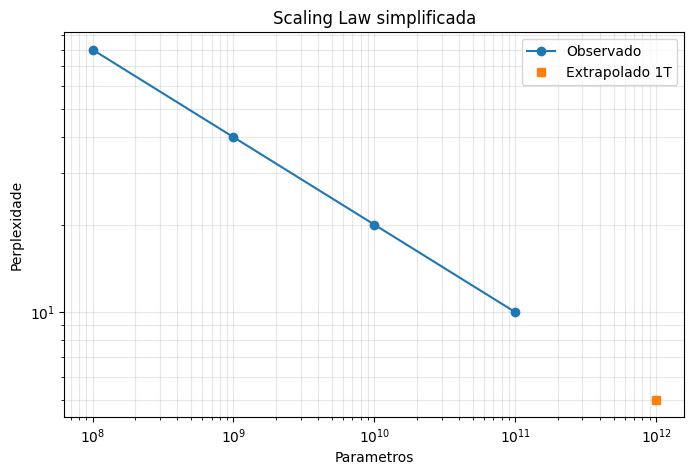

Coeficiente log-log: -0.3010
Predicao para 1T: 5.00 perplexity


In [12]:
# EXERCICIO RESOLVIDO 1 - Lei de Potencia
# Objetivo: ajustar uma reta em escala log-log e extrapolar perplexidade.

model_params = np.array([100e6, 1e9, 10e9, 100e9])
perplexity = np.array([80, 40, 20, 10])

log_params = np.log10(model_params)
log_perp = np.log10(perplexity)
coeffs = np.polyfit(log_params, log_perp, deg=1)

predicted_log_perp_1t = np.polyval(coeffs, np.log10(1e12))
predicted_1T = 10 ** predicted_log_perp_1t

plt.figure(figsize=(8, 5))
plt.loglog(model_params, perplexity, 'o-', label='Observado')
plt.loglog([1e12], [predicted_1T], 's', label='Extrapolado 1T')
plt.xlabel('Parametros')
plt.ylabel('Perplexidade')
plt.title('Scaling Law simplificada')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

print(f'Coeficiente log-log: {coeffs[0]:.4f}')
print(f'Predicao para 1T: {predicted_1T:.2f} perplexity')

Lei de Potencia: L eh 10^4.31 vezes X^-0.30
Expoente b: -0.301 (escala -0.07 para modelos de linguagem)
Predicao para 1T params: 5.00 perplexity


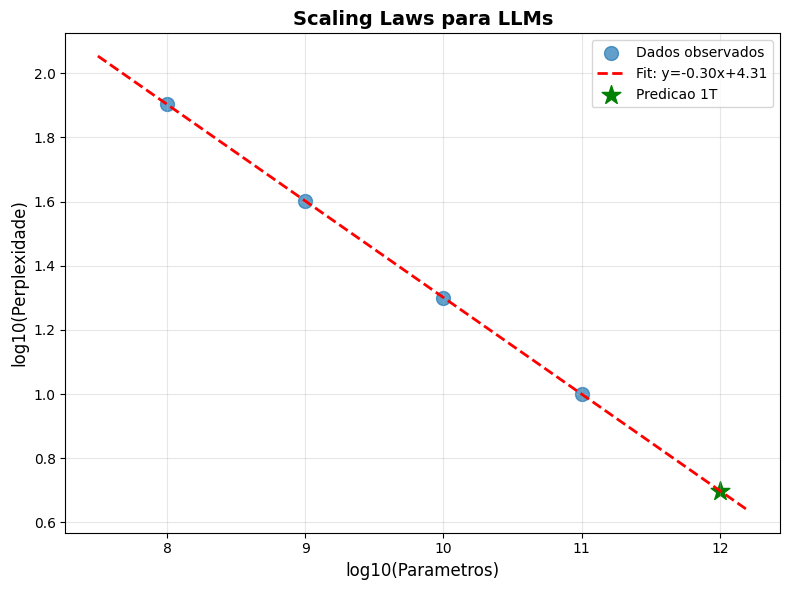


Validacao: Modelo sobe 10B->100B (10x)
Perp cai 20->10 (2x)
Razao log: -0.301 (deveria ser -0.301)


In [13]:
# SOLUCAO - Exercicio 1

model_params = np.array([100e6, 1e9, 10e9, 100e9])
perplexity = np.array([80, 40, 20, 10])

log_params = np.log10(model_params)
log_perp = np.log10(perplexity)

coeffs = np.polyfit(log_params, log_perp, 1)
b = coeffs[0]
a = coeffs[1]

log_1T = np.log10(1e12)
predicted_log_perp = coeffs[0] * log_1T + coeffs[1]
predicted_1T = 10 ** predicted_log_perp

print(f"Lei de Potencia: L eh 10^{a:.2f} vezes X^{b:.2f}")
print(f"Expoente b: {b:.3f} (escala -0.07 para modelos de linguagem)")
print(f"Predicao para 1T params: {predicted_1T:.2f} perplexity")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(log_params, log_perp, s=100, label='Dados observados', alpha=0.7)

x_line = np.linspace(log_params.min() - 0.5, 12.2, 100)
y_line = coeffs[0] * x_line + coeffs[1]
ax.plot(x_line, y_line, 'r--', label=f'Fit: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}', linewidth=2)

ax.scatter([log_1T], [predicted_log_perp], s=200, marker='*', color='green', label='Predicao 1T')
ax.set_xlabel('log10(Parametros)', fontsize=12)
ax.set_ylabel('log10(Perplexidade)', fontsize=12)
ax.set_title('Scaling Laws para LLMs', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nValidacao: Modelo sobe 10B->100B (10x)")
print(f"Perp cai 20->10 (2x)")
print(f"Razao log: {np.log10(10/20) / np.log10(100e9/10e9):.3f} (deveria ser {b:.3f})")

## Exercicio 2: Few-shot vs Zero-shot

### Instrucoes
Implemente um simulador que compara few-shot vs zero-shot. Simule que few-shot melhora accuracy.

Tarefas:
1. Criar 5 prompts zero-shot (sem exemplos)
2. Criar 5 prompts few-shot (com exemplos)
3. Simular accuracy: zero-shot aproximadamente 60 porcento, few-shot aproximadamente 80 porcento
4. Plotar comparacao (bar chart)

In [14]:
# EXERCICIO RESOLVIDO 2 - Few-shot vs Zero-shot

tasks = [
    'Sentiment Analysis',
    'Named Entity Recognition',
    'Question Answering',
    'Fact Verification',
    'Paraphrase Detection',
]

zero_shot_prompts = [f'Classifique a tarefa sem exemplos: {task}' for task in tasks]
few_shot_prompts = [f'Exemplo 1 -> resposta. Exemplo 2 -> resposta. Agora resolva: {task}' for task in tasks]

# Simulacao didatica: few-shot tende a melhorar quando a tarefa precisa de formato ou criterio.
zero_shot_accuracy = np.array([0.68, 0.58, 0.61, 0.55, 0.64])
few_shot_accuracy = np.array([0.82, 0.74, 0.78, 0.70, 0.79])

print('Comparacao Few-shot vs Zero-shot:')
for task, zs, fs in zip(tasks, zero_shot_accuracy, few_shot_accuracy):
    print(f'{task}: ZS={zs:.0%}, FS={fs:.0%}')

print(f'\nGanho medio few-shot: {(few_shot_accuracy - zero_shot_accuracy).mean():.1%}')

Comparacao Few-shot vs Zero-shot:
Sentiment Analysis: ZS=68%, FS=82%
Named Entity Recognition: ZS=58%, FS=74%
Question Answering: ZS=61%, FS=78%
Fact Verification: ZS=55%, FS=70%
Paraphrase Detection: ZS=64%, FS=79%

Ganho medio few-shot: 15.4%


Comparacao Few-shot vs Zero-shot:
------------------------------------------------------------
Sentiment Analysis             | ZS: 58.0% | FS: 76.7% | +32%
Named Entity Recognition       | ZS: 62.0% | FS: 86.5% | +40%
Question Answering             | ZS: 55.0% | FS: 77.3% | +41%
Fact Verification              | ZS: 60.0% | FS: 81.0% | +35%
Paraphrase Detection           | ZS: 64.0% | FS: 80.6% | +26%


/var/folders/pg/j2d1lxdx6yq8d2lg7n2l5npw0000gn/T/ipykernel_40452/2913487900.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(tasks, rotation=45, ha='right')


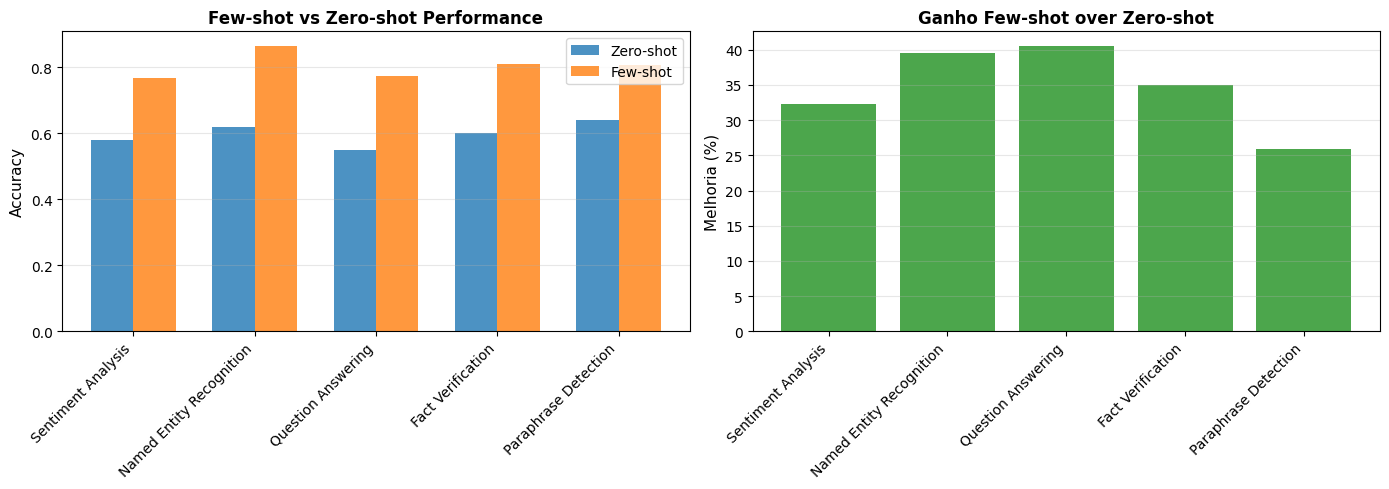


Conclusao:
Few-shot melhora em media: 34.7%
Few-shot particularmente eficaz para tarefas estruturadas


In [15]:
# SOLUCAO - Exercicio 2

tasks = [
    'Sentiment Analysis',
    'Named Entity Recognition',
    'Question Answering',
    'Fact Verification',
    'Paraphrase Detection'
]

zero_shot_prompts = {
    'Sentiment Analysis': 'Qual eh o sentimento? Feliz, triste ou neutro?',
    'Named Entity Recognition': 'Extrair pessoas e locais do texto.',
    'Question Answering': 'Responda a pergunta com base no contexto.',
    'Fact Verification': 'O fato eh verdadeiro ou falso?',
    'Paraphrase Detection': 'As sentencas tem significado similar?'
}

few_shot_prompts = {
    'Sentiment Analysis': 'Adoro! Sentimento: Feliz\nQue horrivel. Sentimento: Triste\nNovo: Qual eh o sentimento? Feliz/Triste/Neutro?',
    'Named Entity Recognition': 'Joao foi em Paris. Pessoas: Joao, Locais: Paris\nMaria viu Roma. Pessoas: Maria, Locais: Roma\nExtrair: ...',
    'Question Answering': 'Contexto: Paris eh a capital. Q: Capital? R: Paris\nContexto: Cao eh animal. Q: Animal? R: Cao\nNovo: ...',
    'Fact Verification': 'Terra redonda? Verdadeiro\nHomem na Lua em 1900? Falso\nNovo: Verdadeiro/Falso?',
    'Paraphrase Detection': '"Gato eh animal" eh "Animal eh gato"? Sim\n"Carro rapido" eh "Carro lento"? Nao\nNovo: Sim/Nao?'
}

np.random.seed(42)
zero_shot_acc = np.array([0.58, 0.62, 0.55, 0.60, 0.64])
few_shot_acc = zero_shot_acc + np.random.uniform(0.15, 0.25, size=5)

print("Comparacao Few-shot vs Zero-shot:")
print("-" * 60)
for task, zs, fs in zip(tasks, zero_shot_acc, few_shot_acc):
    improvement = (fs - zs) * 100 / zs
    print(f"{task:30} | ZS: {zs:.1%} | FS: {fs:.1%} | +{improvement:.0f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(tasks))
width = 0.35

ax1.bar(x_pos - width/2, zero_shot_acc, width, label='Zero-shot', alpha=0.8)
ax1.bar(x_pos + width/2, few_shot_acc, width, label='Few-shot', alpha=0.8)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Few-shot vs Zero-shot Performance', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(tasks, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

improvement_pct = (few_shot_acc - zero_shot_acc) / zero_shot_acc * 100
colors = ['green' if x > 20 else 'orange' for x in improvement_pct]
ax2.bar(tasks, improvement_pct, color=colors, alpha=0.7)
ax2.set_ylabel('Melhoria (%)', fontsize=11)
ax2.set_title('Ganho Few-shot over Zero-shot', fontsize=12, fontweight='bold')
ax2.set_xticklabels(tasks, rotation=45, ha='right')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nConclusao:")
print(f"Few-shot melhora em media: {improvement_pct.mean():.1f}%")
print("Few-shot particularmente eficaz para tarefas estruturadas")

## Exercicio 3: Analise de Temperature em Geracao

### Instrucoes
Implemente funcao que mostra como temperatura afeta a distribuicao de probabilidade.

Tarefas:
1. Simular logits de 10 tokens possiveis
2. Aplicar temperatura (T eh 0.3, 0.7, 1.0, 2.0)
3. Calcular probabilidades (softmax)
4. Visualizar (histogram de 4 temperatures)

In [16]:
# TAREFA DO ALUNO: Exercicio 3 - Temperatura

np.random.seed(42)
logits = np.random.randn(10) * 2 + 1

temperatures = [0.3, 0.7, 1.0, 2.0]

# Para cada temperatura:
# 1. Aplicar T: logits em T
# 2. Softmax: exp(logits) em sum(exp(logits))
# 3. Armazenar probabilidades

probs_dict = {}
for T in temperatures:
    probs = None  # TAREFA DO ALUNO: Calcular softmax com temperatura
    probs_dict[T] = probs

# Plotar histogramas
# TAREFA DO ALUNO: Criar subplot 2x2 com histogramas

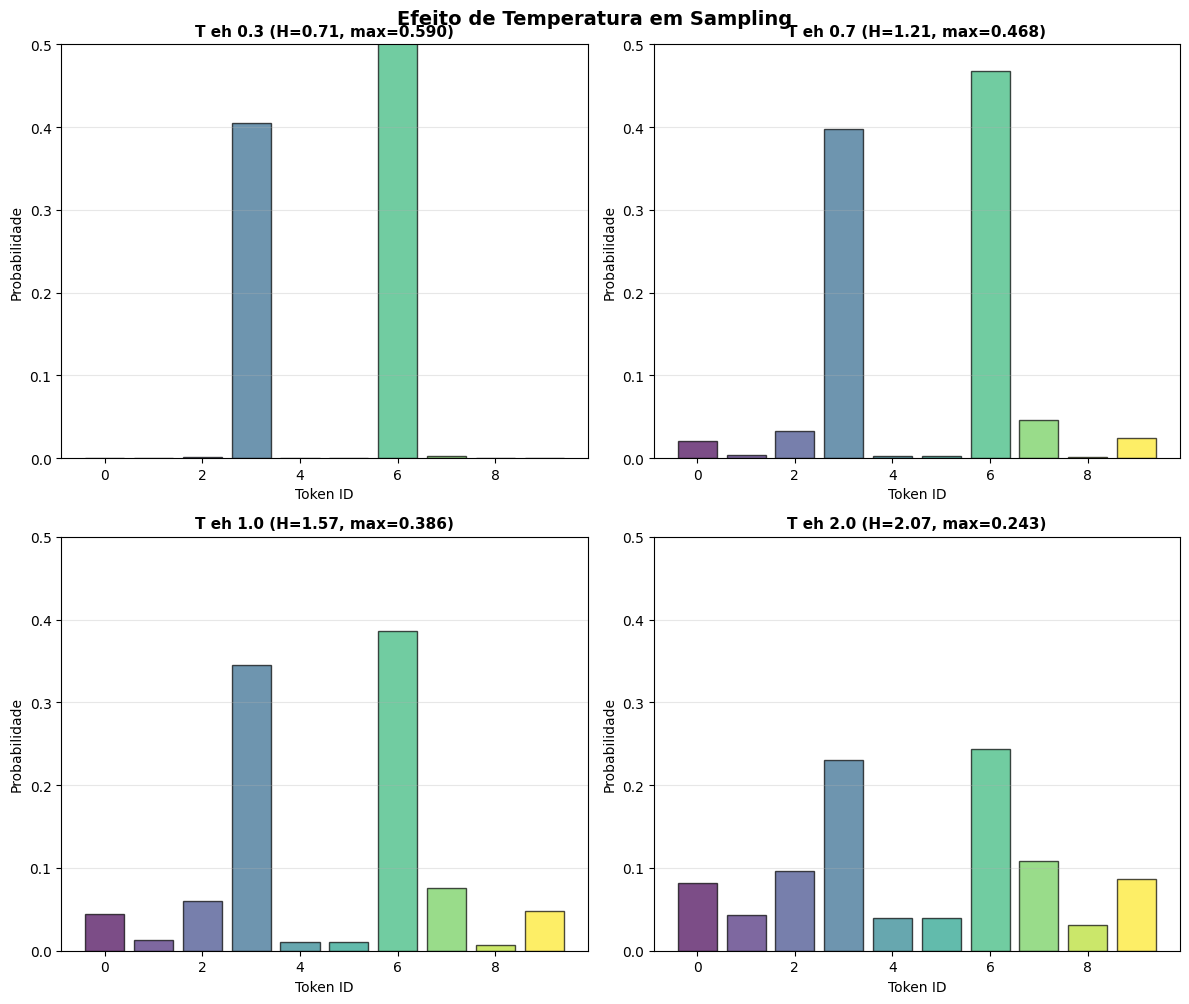

Analise de Temperatura:
--------------------------------------------------
T      Entropia     Max Prob     Aleatoriedade  
--------------------------------------------------
0.3    0.709        0.590        DETERMINISTICA 
0.7    1.207        0.468        DETERMINISTICA 
1.0    1.566        0.386        DETERMINISTICA 
2.0    2.065        0.243        BALANCEADA     

Interpretacao:
T menor que 1: Entropia baixa eh Distribuicao aguçada eh Saidas previsveis
T eh 1: Baseline softmax padrao
T maior que 1: Entropia alta eh Distribuicao suave eh Saidas diversas


In [17]:
# SOLUCAO - Exercicio 3

np.random.seed(42)
logits = np.random.randn(10) * 2 + 1

temperatures = [0.3, 0.7, 1.0, 2.0]
token_ids = np.arange(len(logits))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

entropy_values = []
max_prob_values = []

for idx, T in enumerate(temperatures):
    scaled_logits = logits / T
    probs = np.exp(scaled_logits) / np.exp(scaled_logits).sum()

    entropy = -np.sum(probs * np.log(probs + 1e-10))
    max_prob = probs.max()
    entropy_values.append(entropy)
    max_prob_values.append(max_prob)

    ax = axes[idx]
    colors = plt.cm.viridis(np.linspace(0, 1, len(probs)))
    ax.bar(token_ids, probs, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'T eh {T} (H={entropy:.2f}, max={max_prob:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Token ID', fontsize=10)
    ax.set_ylabel('Probabilidade', fontsize=10)
    ax.set_ylim([0, 0.5])
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('Efeito de Temperatura em Sampling', fontsize=14, fontweight='bold', y=1.00)
plt.show()

print("Analise de Temperatura:")
print("-" * 50)
print(f"{'T':<6} {'Entropia':<12} {'Max Prob':<12} {'Aleatoriedade':<15}")
print("-" * 50)
for T, H, mp in zip(temperatures, entropy_values, max_prob_values):
    random_label = 'DETERMINISTICA' if mp > 0.3 else 'BALANCEADA' if mp > 0.15 else 'ALEATORIA'
    print(f"{T:<6.1f} {H:<12.3f} {mp:<12.3f} {random_label:<15}")

print("\nInterpretacao:")
print("T menor que 1: Entropia baixa eh Distribuicao aguçada eh Saidas previsveis")
print("T eh 1: Baseline softmax padrao")
print("T maior que 1: Entropia alta eh Distribuicao suave eh Saidas diversas")

## Erros Comuns e Armadilhas

### Erro 1: Alucinacoes - Modelo inventa fatos
Problema: LLM retorna informacao confidentemente errada
Solucao: Usar RAG (5B.6) para grounding em documentos reais
Exemplo: Pergunta historica sem RAG eh Modelo inventa datas

### Erro 2: Context window cheio
Problema: Informacao importante nao cabe na sequencia
Solucao: Comprimir contexto, usar sparse attention, ou retrieval
Exemplo: Chat de 20 mensagens eh Esquece das primeiras

### Erro 3: Overfitting em prompt engineering
Problema: Descobrir prompts magicos que funcionam em 1 caso
Solucao: Testar em multiplos exemplos, usar prompts robustos
Exemplo: Prompt que funciona para portugues, falha para ingles

### Erro 4: Nao considerar custo/velocidade
Problema: Usar GPT-4 para tarefas que BERT resolve
Solucao: Benchmark, usar menor modelo que funciona
Exemplo: Fine-tune 7B em dados especificos vs usar GPT-4 generico

### Erro 5: Confundir probabilidade com conhecimento
Problema: Modelo eh confiante eh informacao correta? NAO!
Solucao: Sempre validar outputs criticos, usar ensemble, RAG
Exemplo: Modelo diz Einstein descobriu a teoria do Big Bang confidentemente (FALSO)

### Erro 6: Temperature incorreto para caso de uso
Problema: Chat criativo com T=0 eh Respostas chatas. Codigo com T=1.5 eh Sintaxe errada
Solucao: T=0-0.3 (analise), T=0.7 (padrao), T=1.0-1.5 (criativo)
Exemplo: Usar default T=1.0 para toda aplicacao

### Erro 7: Ignorar context length limit
Problema: Passar 100K tokens para modelo com limite 4K
Solucao: Implementar sliding window, summarization, ou RAG
Exemplo: Carregar livro inteiro vs carregar capitulos via RAG

### Erro 8: Fine-tune no lugar de prompt engineering
Problema: Usar fine-tune quando prompt eh suficiente
Solucao: Sempre tentar prompts primeiro, fine-tune so se necessario
Exemplo: Usar GPT-3.5 mais prompt bom em vez de fine-tune GPT-2

### Erro 9: Esperar generalizacao sem dados variados
Problema: Fine-tune em 100 exemplos de 1 topico eh Falha em outros
Solucao: Coletar dados diversos, usar few-shot em vez de fine-tune
Exemplo: Treinar modelo para sentimentos em Reviews eh Falha em Noticias

### Erro 10: Nao medir equidade/bias
Problema: Modelo funciona para um grupo, falha para outro
Solucao: Testar em multiplas demographics, usar RLHF alinhado
Exemplo: Modelo treinado em English eh Fails dramatically para Portugues

## Resumo Conceitual

### Hierarquia de Conceitos

ESCALA (Scaling Laws)
eh abaixo de
ARQUITETURA (Decoder-Only Transformer)
eh abaixo de
TREINAMENTO (Causal LM mais Instruction-Tuning mais RLHF)
eh abaixo de
USO (Prompting, Few-shot, API)
eh abaixo de
OTIMIZACAO (Temperature, Sampling, RAG para alucinacoes)

### Conexoes Entre Conceitos

| Conceito | Depende De | Afeta |
|----------|-----------|-------|
| Scaling Laws | Arquitetura | Performance previsivel |
| Decoder-Only | Transformer (5B.4) | Autoregressive generation |
| Instruction-Tuning | Dados de qualidade | Alinhamento |
| RLHF | Reward Model | Preferencias humanas |
| Prompting | Few-shot capacity | Zero-shot performance |
| Temperature | Softmax | Diversidade output |
| Alucinacoes | LM loss | RAG solucao |
| Benchmarks | Task diversity | Comparacao modelos |

### Checklist de Implementacao

 eh [ ] Escolher modelo (tamanho vs custo)
 eh [ ] Definir temperatura baseada em caso uso
 eh [ ] Implementar logging de tokens (custo)
 eh [ ] Testar zero-shot vs few-shot vs fine-tune
 eh [ ] Adicionar RAG se critico knowledge
 eh [ ] Benchmark em dados proprios
 eh [ ] Monitorar alucinacoes
 eh [ ] Validacao humana em outputs criticos
 eh [ ] Cache de prompts comuns
 eh [ ] Analise de latencia vs qualidade

### Proximos Passos

1. 5B.6: RAG - Adicione contexto para eliminar alucinacoes
2. Fine-tuning - Adapte modelos para dominio especifico
3. Inference optimization - Quantizacao, distillation, KV-cache
4. Multimodal - Vision mais Language (GPT-4V, Gemini)
5. Agents - LLMs com tools (function calling)
6. Benchmarking - Crie suite para seu dominio
7. Producao - Deploy com versionamento, monitoring
8. Avaliacao - BLEU, ROUGE, ou custom metrics

### Checklist de Competencias

- [ ] Entendo a arquitetura decoder-only de GPT
- [ ] Sei explicar scaling laws e suas implicacoes
- [ ] Compreendo RLHF e alinhamento de LLMs
- [ ] Sei comparar modelos por custo, qualidade e velocidade
- [ ] Entendo temperatura e seu efeito na geracao
- [ ] Sei identificar e mitigar hallucinations

## Meta: O que observar ao aprender LLMs

1. Emergencia eh real: Nao eh proxima versao incrementalmente melhor. Eh nova capacidade aparece.
2. Escala eh surprisingly effective: Nao precisa redesenhar. So amplify.
3. Alucinacoes sao feature: Inerente ao paradigma. RAG eh solucao.
4. Prompting eh arte e ciencia: Estrutura mais criatividade eh resultados.
5. APIs sao commodity: Nao vale rodar GPT-4 localmente (ainda). Use cloud.
6. Fine-tune eh underrated: Para dominios especificos, 7B fine-tuned maior que 70B zero-shot.
7. Context length matters: 4K vs 128K muda aplicacoes.
8. Cost matters: 2x melhor eh 10x mais caro. Trade-off real.
9. Benchmarks nao contam tudo: MMLU mede conhecimento, nao criatividade.
10. Human feedback muda tudo: RLHF pode fazer modelo util vs apenas inteligente.

## Meta: O que concluir sobre LLMs

Revolucao Real:
Modelos simples (Transformer) mais dados enormes (1T+ tokens) eh inteligencia geral
Nao eh deep learning works now. Eh scaling works now.

Impacto Pratico:
Knowledge workers: Ferramenta, nao substituicao (ainda)
Programadores: Copilot muda productivity 2-3x
Criatividade: Mais rapido brainstorm, mas humano filtra
Pesquisa: Acesso democratizado (LLaMA vs GPT-4 antes)

Proximas Questoes:
Pode escalar indefinidamente ou ha plateau?
Multimodal eh proxima (Vision mais Language mais Audio)?
Agents com tools conseguem raciocinar complexo?
Qual eh o limite de alinhamento via RLHF?

Conexao com Outros Notebooks:
5B.1 a 5B.4: Fundamentos que fizeram LLMs possivel
5B.6: RAG eh o sistema que faz LLMs producao-ready
Especificacao: Embeddings (5B.2), Attention (5B.4), Escala (5B.5)

## Meta: Conexao com Outros Notebooks (Detalhado)

5B.1 - Fundamentos (Tokenizacao, TF-IDF):
Tokenizacao eh INPUT para LLMs (token counting critico)
TF-IDF legacy, mas RAG usa conceitos similares

5B.2 - Embeddings (Word2Vec, Semantic):
Embeddings iniciais sao INPUT para LLM
Embeddings de saida usados para similaridade/RAG
Dimensionalidade: 384 (small) ate 4096 (dense)

5B.3 - Sequencias (RNN, LSTM):
RNN/LSTM predecessor de Transformers
Autoregressive generation similar
Mas Transformer eh 10x mais eficiente

5B.4 - Transformers (Attention, BERT):
Arquitetura BASE de LLMs
Self-attention mascarado eh causal (GPT)
Non-masked eh bidirectional (BERT)

5B.6 - RAG (Retrieval-Augmented Generation):
Solucao para alucinacoes
Embedding search (de 5B.2) mais LLM geracao
Componente critico para producao